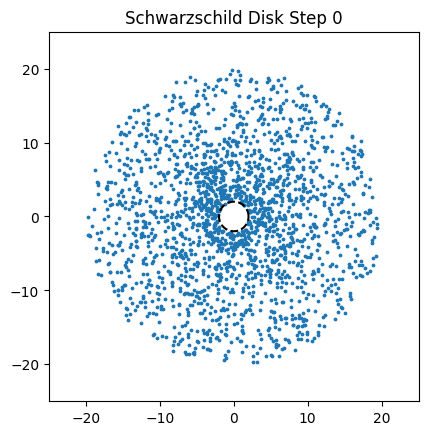

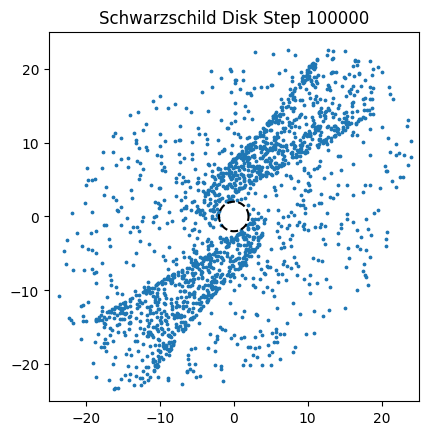

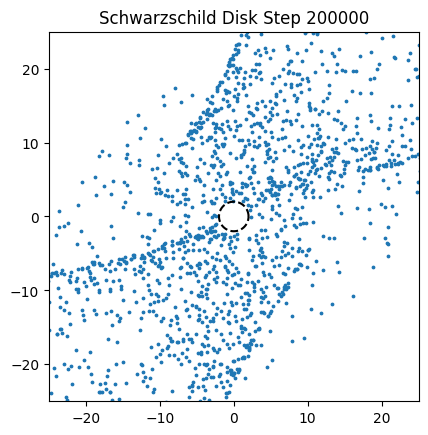

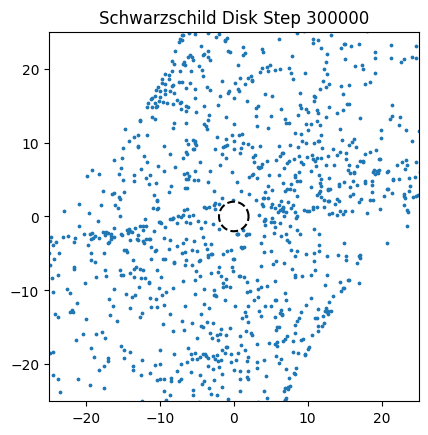

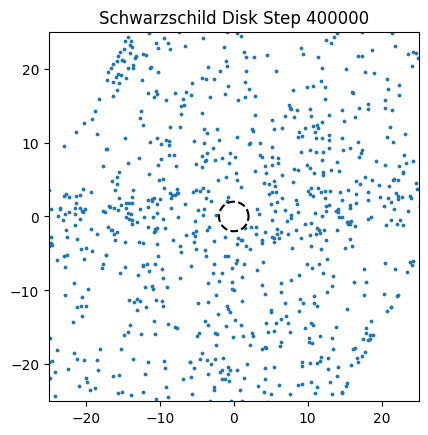

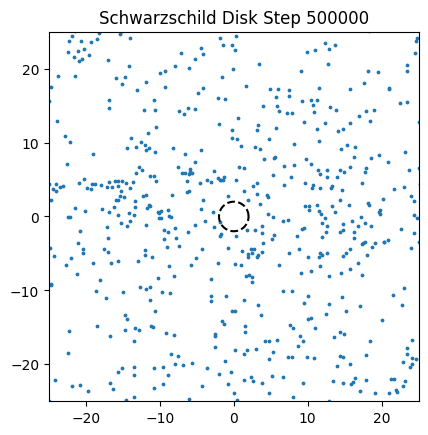

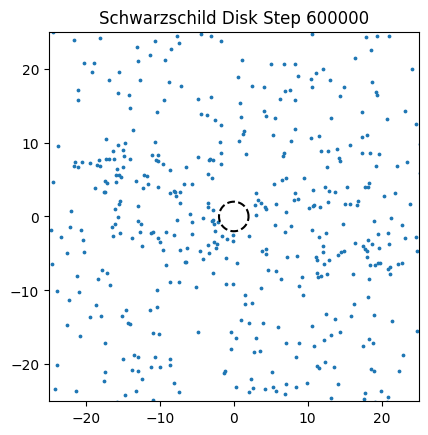

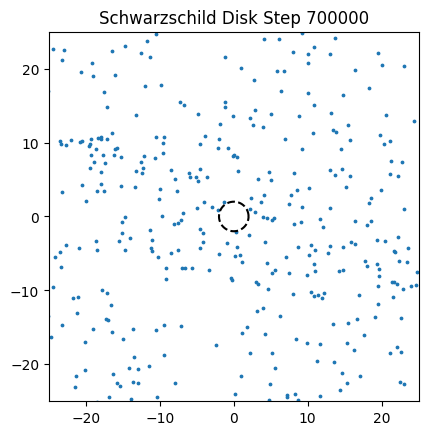

KeyboardInterrupt: 

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# =============================
# Parameters
# =============================
M = 1.0
dt = 1e-4
N = 2000

# =============================
# Coordinate transforms
# =============================
def polar_to_cartesian(r, phi):
    return r*np.cos(phi), r*np.sin(phi)

# =============================
# Initialize disk in GR
# =============================
def initialize_disk_GR(N,inner_r=2*M,outer_r = 20* M,e0=0.001):
    r0 = np.random.uniform(inner_r, outer_r, N)   # guiding center radius
    phi = np.random.uniform(0, 2*np.pi, N)

    # Small eccentricity (can randomize per particle if desired)
    e = e0 * np.ones(N)

    # Epicyclic phase
    psi = np.random.uniform(0, 2*np.pi, N)

    # Radial perturbation (eccentricity)
    r = r0 * (1 + e * np.cos(psi))

    # GR circular angular velocity (approx)
    Omega = np.sqrt(M / r0**3)

    # Tangential velocity (slightly modulated)
    vphi = Omega * (1 - 2 * e * np.cos(psi))

    # Radial velocity (key for eccentric motion)
    vr = - e * r0 * Omega * np.sin(psi)

    # Time component (still approximate)
    vt = np.ones(N)

    return r, phi, vr, vphi, vt

# =============================
# GR evolution step
# =============================
def step_GR(r, phi, vr, vphi, vt, drag=0.1, r_capture=2.05*M):
    
    # Christoffel symbols
    Gamma_r_tt = M*(r-2*M)/r**3
    Gamma_r_rr = -M/(r*(r-2*M))
    Gamma_r_pp = -(r-2*M)
    Gamma_t_tr = M/(r*(r-2*M))
    Gamma_p_rp = 1/r

    # accelerations
    ar = -Gamma_r_tt*vt**2 - Gamma_r_rr*vr**2 - Gamma_r_pp*vphi**2
    aphi = -2*Gamma_p_rp*vr*vphi
    at = -2*Gamma_t_tr*vt*vr

    # Optional viscous drag
    ar -= drag * vr
    aphi -= drag * vphi

    # update velocities
    vr += ar * dt
    vphi += aphi * dt
    vt += at * dt

    # update positions
    r += vr * dt
    phi += vphi * dt

    # =============================
    # Black hole capture condition
    # =============================
    mask = r > r_capture

    # Apply mask to ALL phase space variables
    r = r[mask]
    phi = phi[mask]
    vr = vr[mask]
    vphi = vphi[mask]
    vt = vt[mask]

    return r, phi, vr, vphi, vt

# =============================
# Initialize disk
# =============================
r, phi, vr, vphi, vt = initialize_disk_GR(N)

# Add m=2 perturbation (spiral seed)
vphi += 0.1 * np.cos(2*phi)

# =============================
# Time evolution
# =============================
for i in range(100000):

    r, phi, vr, vphi, vt = step_GR(r, phi, vr, vphi, vt, drag=0.001)

    # Remove particles that fall inside horizon
    # mask = r > 2.2*M
    # r, phi, vr, vphi, vt = r[mask], phi[mask], vr[mask], vphi[mask], vt[mask]

    if i % 10000 == 0:
        plt.clf()

        x, y = polar_to_cartesian(r, phi)
        plt.scatter(x, y, s=3)

        # Event horizon
        theta = np.linspace(0, 2*np.pi, 200)
        plt.plot(2*M*np.cos(theta), 2*M*np.sin(theta), 'k--')

        plt.gca().set_aspect('equal')
        plt.xlim(-25, 25)
        plt.ylim(-25, 25)
        plt.title(f"Schwarzschild Disk Step {i}")
        plt.pause(0.01)

plt.show()

In [ ]:
def compute_observables(r, phi, vr, vphi):
    # wrap phi to [0, 2π]
    phi = np.mod(phi, 2*np.pi)
    return r, phi, vr, vphi
def plot_radial_profiles(r, vr, vphi, nbins=50):
    bins = np.linspace(r.min(), r.max(), nbins)
    centers = 0.5 * (bins[:-1] + bins[1:])
    
    counts = np.zeros(nbins-1)
    vr_mean = np.zeros(nbins-1)
    vphi_mean = np.zeros(nbins-1)
    
    for i in range(nbins-1):
        mask = (r >= bins[i]) & (r < bins[i+1])
        if np.any(mask):
            counts[i] = np.sum(mask)
            vr_mean[i] = np.mean(vr[mask])
            vphi_mean[i] = np.mean(vphi[mask])
    
    fig, axs = plt.subplots(3, 1, figsize=(6, 10))
    
    axs[0].plot(centers, counts)
    axs[0].set_ylabel("Density (counts/circumfrence)")
    axs[0].set_xlabel("r")
    
    axs[1].plot(centers, vr_mean)
    axs[1].set_ylabel("⟨v_r⟩")
    axs[1].set_xlabel("r")
    
    axs[2].plot(centers, vphi_mean)
    axs[2].set_ylabel("⟨v_φ⟩")
    axs[2].set_xlabel("r")
    
    plt.tight_layout()
    plt.show()
def plot_angular_profiles(phi, vr, vphi, nbins=60):
    bins = np.linspace(0, 2*np.pi, nbins)
    centers = 0.5 * (bins[:-1] + bins[1:])
    
    counts = np.zeros(nbins-1)
    vr_mean = np.zeros(nbins-1)
    vphi_mean = np.zeros(nbins-1)
    
    for i in range(nbins-1):
        mask = (phi >= bins[i]) & (phi < bins[i+1])
        if np.any(mask):
            counts[i] = np.sum(mask)
            vr_mean[i] = np.mean(vr[mask])
            vphi_mean[i] = np.mean(vphi[mask])
    
    fig, axs = plt.subplots(3, 1, figsize=(6, 10))
    
    axs[0].plot(centers, counts)
    axs[0].set_ylabel("Density")
    axs[0].set_xlabel("φ")
    
    axs[1].plot(centers, vr_mean)
    axs[1].set_ylabel("⟨v_r⟩")
    axs[1].set_xlabel("φ")
    
    axs[2].plot(centers, vphi_mean)
    axs[2].set_ylabel("⟨v_φ⟩")
    axs[2].set_xlabel("φ")
    
    plt.tight_layout()
    plt.show()
def plot_density_r_phi(r, phi, nbins_r=60, nbins_phi=60):
    H, r_edges, phi_edges = np.histogram2d(
        r, phi, bins=[nbins_r, nbins_phi]
    )
    
    plt.figure(figsize=(7,5))
    plt.imshow(
        H.T,
        origin='lower',
        aspect='auto',
        extent=[r_edges[0], r_edges[-1], phi_edges[0], phi_edges[-1]]
    )
    plt.colorbar(label="Density")
    plt.xlabel("r")
    plt.ylabel("φ")
    plt.title("Density in (r, φ)")
    plt.show()
def plot_velocity_maps(r, phi, vr, vphi, nbins=50):
    r_bins = np.linspace(r.min(), r.max(), nbins)
    phi_bins = np.linspace(0, 2*np.pi, nbins)
    
    vr_map = np.zeros((nbins-1, nbins-1))
    vphi_map = np.zeros((nbins-1, nbins-1))
    counts = np.zeros((nbins-1, nbins-1))
    
    for i in range(len(r)):
        ir = np.searchsorted(r_bins, r[i]) - 1
        ip = np.searchsorted(phi_bins, phi[i]) - 1
        
        if 0 <= ir < nbins-1 and 0 <= ip < nbins-1:
            vr_map[ir, ip] += vr[i]
            vphi_map[ir, ip] += vphi[i]
            counts[ir, ip] += 1
    
    mask = counts > 0
    vr_map[mask] /= counts[mask]
    vphi_map[mask] /= counts[mask]
    
    extent = [r_bins[0], r_bins[-1], phi_bins[0], phi_bins[-1]]
    
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.imshow(vr_map.T, origin='lower', aspect='auto', extent=extent)
    plt.colorbar(label="v_r")
    plt.xlabel("r")
    plt.ylabel("φ")
    
    plt.subplot(1,2,2)
    plt.imshow(vphi_map.T, origin='lower', aspect='auto', extent=extent)
    plt.colorbar(label="v_φ")
    plt.xlabel("r")
    plt.ylabel("φ")
    
    plt.tight_layout()
    plt.show()

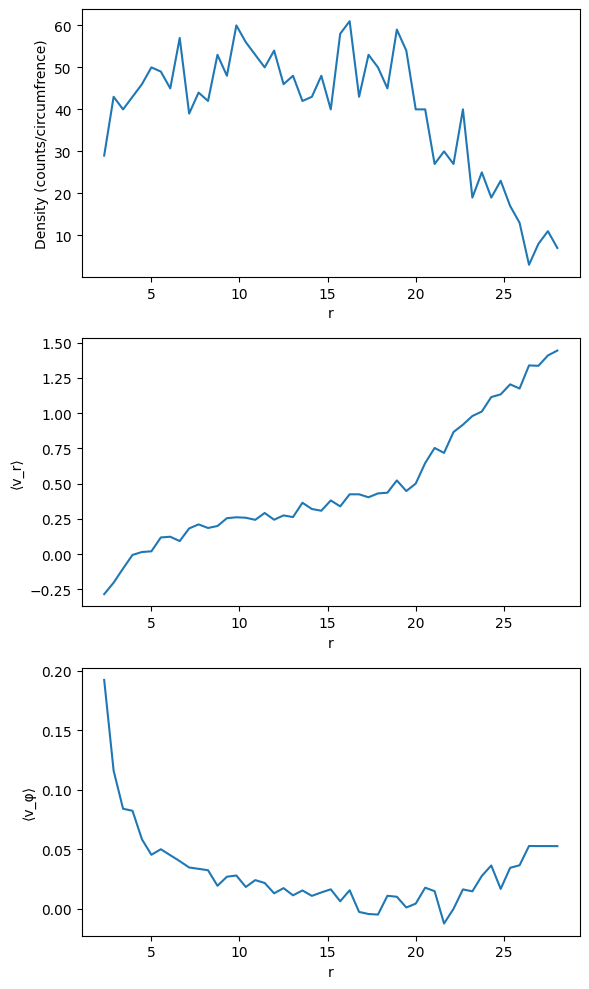

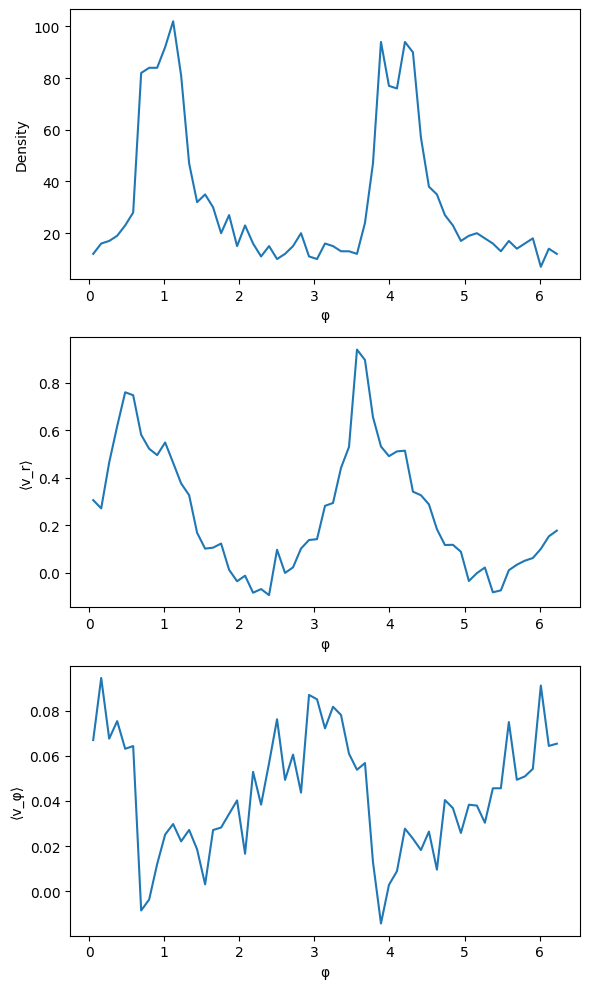

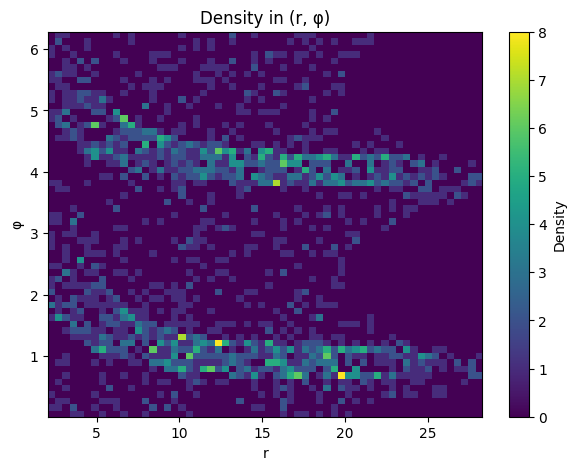

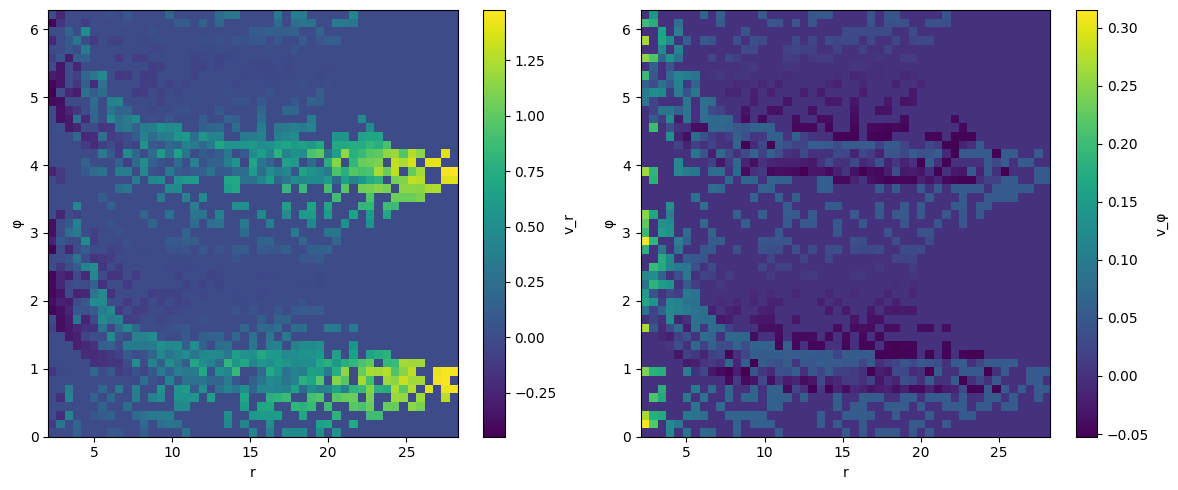

In [ ]:
r, phi, vr, vphi = compute_observables(r, phi, vr, vphi)

plot_radial_profiles(r, vr, vphi)
plot_angular_profiles(phi, vr, vphi)
plot_density_r_phi(r, phi)
plot_velocity_maps(r, phi, vr, vphi)